In [1]:
# Clean & Fast Setup (run once per session)
import os, sys, subprocess
from pathlib import Path

repo_url = "https://github.com/Leibniz-IWT/comp_eng.git"
repo_dir = "comp_eng"

if not Path(repo_dir).exists():
    print("Cloning repository (shallow clone - fast)...")
    !git clone --depth 1 {repo_url} {repo_dir} -q
else:
    print("Repository already cloned.")

%cd {repo_dir}/project_handout

# Make station_model importable
sys.path.insert(0, os.path.abspath("."))

# Install dependencies quietly
print("Installing dependencies...")
!pip install -q numpy scipy matplotlib sympy gymnasium stable-baselines3[extra] ipywidgets


print("✅ Setup complete! You can now open the handout notebook.")

Cloning repository (shallow clone - fast)...
/content/comp_eng/project_handout
Installing dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 50.1 MB/s eta 0:00:00
✅ Setup complete! You can now open the handout notebook.


In [2]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from numpy.f2py.crackfortran import verbose
from stable_baselines3 import PPO
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import inspect

from station_model._hidden_functions import drag_interp, thrust_main_interp, thrust_rot_interp

from station_model._environment import OrbitMaintenanceEnv, run_simulation, plot_simulation

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Starting Training... (Target: 200,000 timesteps)
This may take 10-20 minutes depending on your computer speed.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------
| time/              |      |
|    fps             | 75   |
|    iterations      | 1    |
|    time_elapsed    | 27   |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 71           |
|    iterations           | 2            |
|    time_elapsed         | 57           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0048520966 |
|    clip_fraction        | 0.0271       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.84        |
|    explained_variance   | -0.000823    |
|    learning_rate        | 0.0003       |
|    loss                 | 201          |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00284     |
|    std                  | 1            |
|    value_loss           | 635          |
----------------

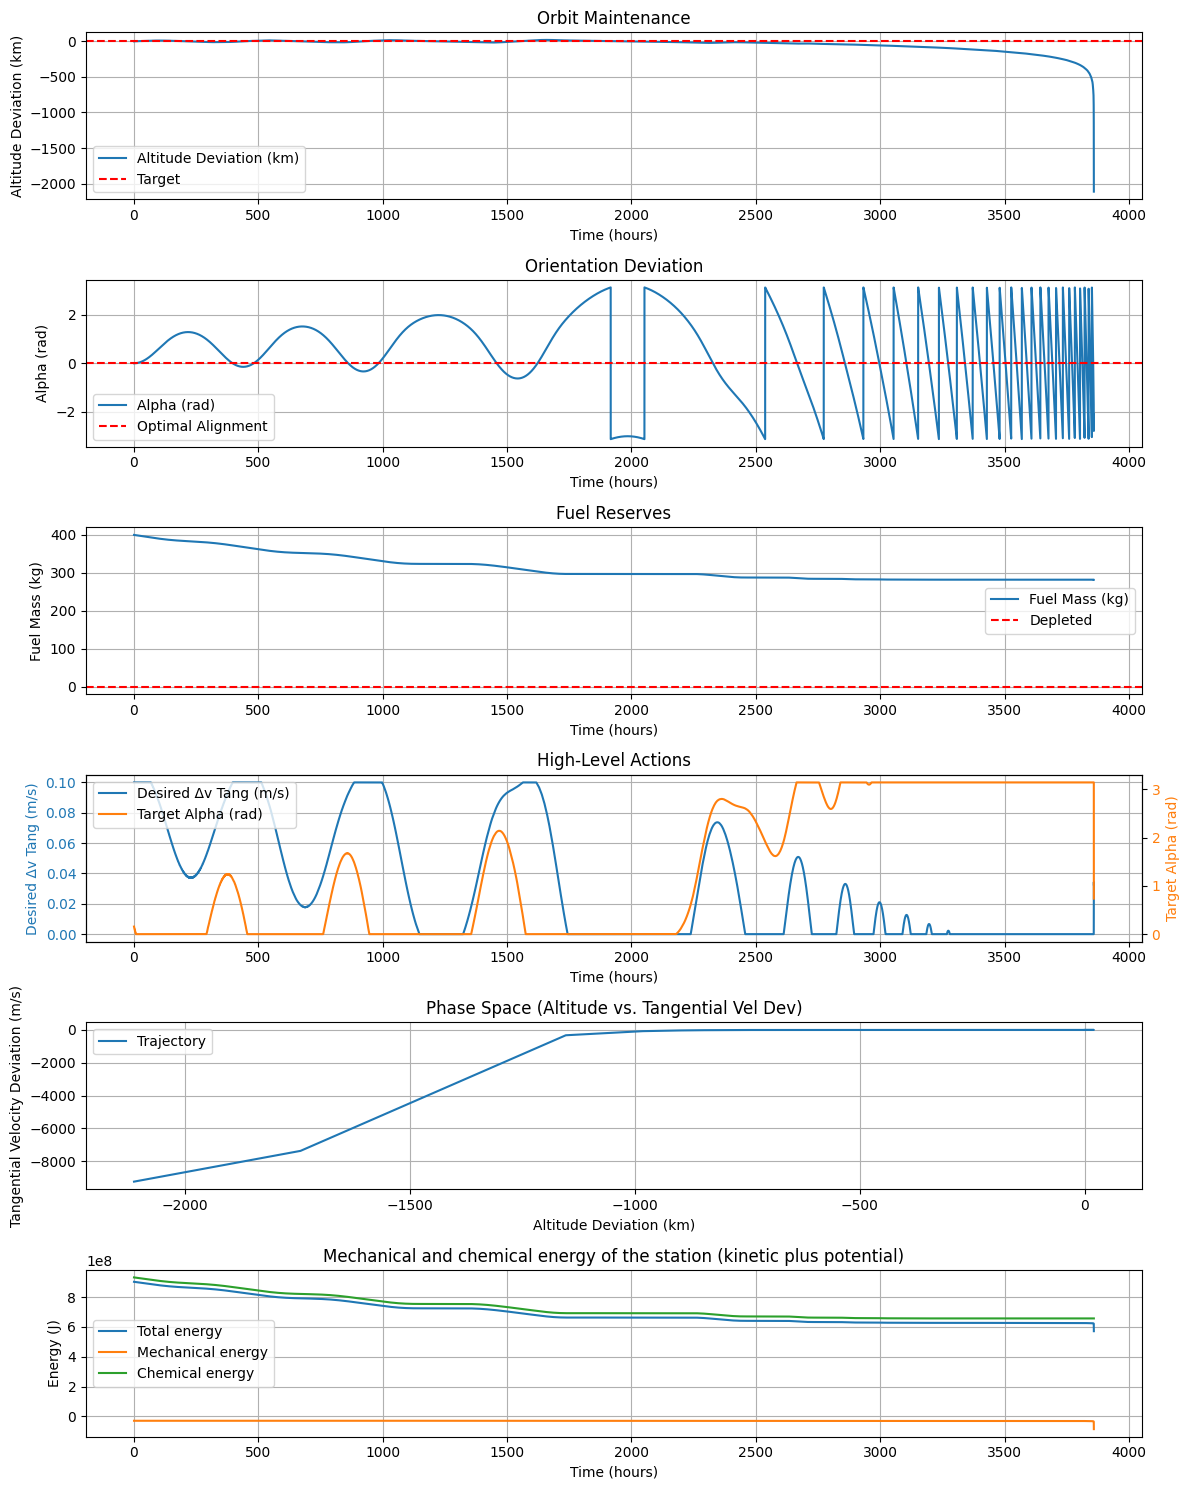

In [3]:
import numpy as np
from stable_baselines3 import PPO
from types import MethodType
from station_model._environment import OrbitMaintenanceEnv, run_simulation

# ==========================================
# 1. Define Custom Reward Function (The Strategy)
# ==========================================
def smart_survival_reward(self):
    """
    Custom reward function to replace the default one.
    Prioritizes survival (altitude) above all else, then fuel conservation.
    """
    # --- Extract State Variables ---
    # Current distance from earth center
    r = self.current_r
    # Target distance (Radius of Earth + Initial Altitude)
    r_target = self.R_earth + self.initial_altitude
    # Deviation (Negative means we are falling, Positive means we are drifting away)
    delta_alt = r - r_target

    # Calculate orientation misalignment (alpha)
    v_x = self.current_v_r
    v_y = self.current_v_theta
    # Angle of the velocity vector
    theta_v = np.arctan2(v_y, v_x)
    # Alpha is the difference between pointing angle and velocity angle
    # We normalize it to be between -pi and pi
    alpha = (self.current_psi - theta_v + np.pi) % (2 * np.pi) - np.pi

    # --- Reward Components ---

    # 1. Living Bonus (Crucial for Survival)
    # The agent gets points just for not crashing. This encourages it to keep the
    # episode going as long as possible (up to 180 days).
    reward = 10.0

    # 2. Altitude Penalty (Asymmetric)
    # If we are BELOW target (delta_alt < 0), the drag is higher and we risk crashing.
    # We punish this 4x harder than being above target.
    # Normalizing by 1000m to keep numbers reasonable.
    if delta_alt < 0:
        reward -= 2.0 * (abs(delta_alt) / 1000.0)
    else:
        reward -= 0.5 * (abs(delta_alt) / 1000.0)

    # 3. Orientation Penalty
    # Misalignment (alpha) causes massive drag. We punish non-zero alpha.
    reward -= 5.0 * abs(alpha)

    # 4. Fuel Penalty (Emergency Conservation)
    # We heavily punish the agent if fuel drops below 50kg, forcing it to be efficient.
    if self.fuel_mass < 50:
        reward -= 50.0

    return reward

# ==========================================
# 2. Setup Environment & Agent
# ==========================================

# Initialize the environment
env = OrbitMaintenanceEnv()

# Inject our custom reward function into the environment
# This overwrites the default logic with our "smart_survival_reward"
env.reward_function = MethodType(smart_survival_reward, env)

# Reset environment to apply changes
env.reset()

# Initialize the PPO Agent
# - learning_rate=3e-4: Standard stable rate for PPO.
# - gamma=0.999: High discount factor makes the agent care about the long-term future (180 days).
# - batch_size=64: Good balance for learning stability.
model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=3e-4,
    gamma=0.999,
    batch_size=64,
    n_steps=2048           # Number of steps to run per update
)

# ==========================================
# 3. Train the Agent
# ==========================================
print("Starting Training... (Target: 200,000 timesteps)")
print("This may take 10-20 minutes depending on your computer speed.")

# Train for 200,000 steps.
# 50k is often enough to pass, but 200k is needed to learn fuel efficiency for the full 180 days.
model.learn(total_timesteps=200000)

print("Training Complete!")

# ==========================================
# 4. Save and Test
# ==========================================

# Save the model
model_name = "ppo_180_day_survival_agent"
model.save(model_name)
print(f"Model saved as {model_name}")

# Define the policy wrapper required by the simulation function
def trained_policy(obs):
    # Predict the action using our trained model (deterministic=True removes randomness)
    action, _ = model.predict(obs, deterministic=True)
    return action

# Run the simulation visualization and scoring
print("Running Validation Simulation...")
data = run_simulation(env, trained_policy)
